# E-commerce Customer Behavior & Market Basket Analysis
## Executive Report & Exploratory Analysis

**Prepared by:** Exploratory Analysis Lead & Storytelling Lead

### Executive Summary
This report provides a comprehensive analysis of customer transaction data to uncover demographic trends, identify key revenue drivers, and understand customer retention patterns. The insights derived below are intended to guide strategic decision-making in marketing, inventory management, and customer experience enhancements.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Set seaborn style for premium visuals
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)

# Load the cleaned dataset
try:
    df = pd.read_csv('data/cleaned/ecommerce_customer_data_cleaned.csv')
    print(f"Data loaded successfully. Total Records Analyzed: {len(df):,}")
except FileNotFoundError:
    print("Please run 01_cleaning.ipynb first to generate the cleaned dataset.")

Data loaded successfully. Total Records Analyzed: 250,000


---
## 1. Customer Demographics
Understanding *who* our customers are is the first step to serving them better. The charts below illustrate the distribution of our customers by age and gender.

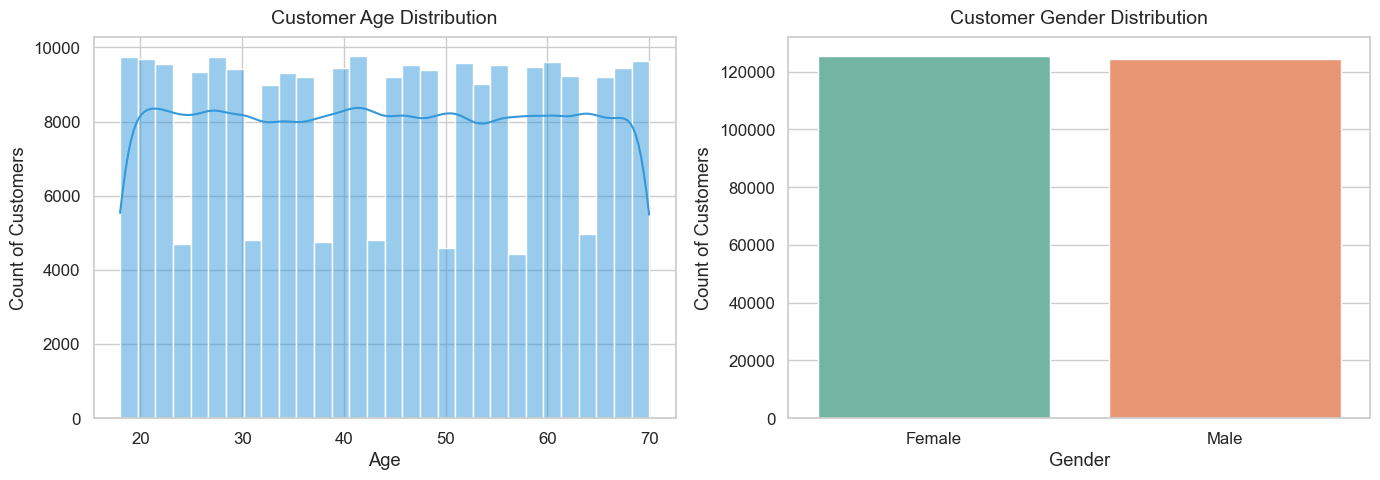

In [2]:
if 'df' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.histplot(data=df, x='Age', bins=30, kde=True, color='#3498db', ax=axes[0])
    axes[0].set_title('Customer Age Distribution', fontsize=14, pad=10)
    axes[0].set_xlabel('Age')
    axes[0].set_ylabel('Count of Customers')
    
    sns.countplot(data=df, x='Gender', hue='Gender', palette='Set2', ax=axes[1], legend=False)
    axes[1].set_title('Customer Gender Distribution', fontsize=14, pad=10)
    axes[1].set_xlabel('Gender')
    axes[1].set_ylabel('Count of Customers')
    
    plt.tight_layout()
    plt.show()

**Insight:** The age distribution provides clarity on our core demographic age groups, while the gender split informs targeted marketing campaigns.

---
## 2. Revenue Drivers and Purchase Behavior
To maximize profitability, we must identify which product categories generate the most revenue and observe how purchase amounts vary across these categories.

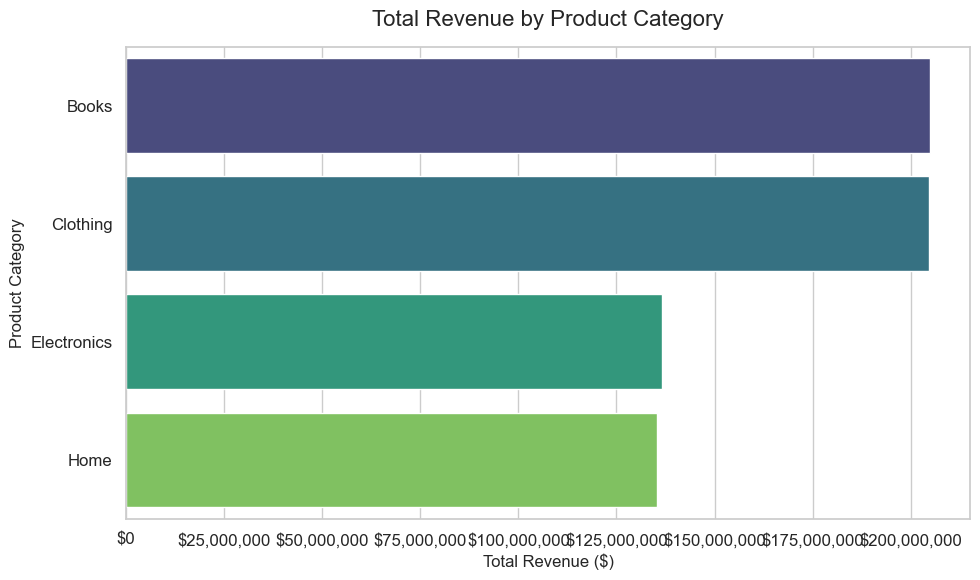

In [3]:
if 'df' in locals():
    plt.figure(figsize=(10, 6))
    category_revenue = df.groupby('Product Category')['Total Purchase Amount'].sum().sort_values(ascending=False)
    sns.barplot(x=category_revenue.values, y=category_revenue.index, hue=category_revenue.index, palette='viridis', legend=False)
    
    plt.title('Total Revenue by Product Category', fontsize=16, pad=15)
    plt.xlabel('Total Revenue ($)', fontsize=12)
    plt.ylabel('Product Category', fontsize=12)
    
    # Add formatting to the x-axis for readability
    current_values = plt.gca().get_xticks()
    plt.gca().set_xticklabels(['${:,.0f}'.format(x) for x in current_values])
    
    plt.tight_layout()
    plt.show()

In [ ]:
if 'df' in locals():
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='Product Category', y='Total Purchase Amount', hue='Product Category', palette='pastel', legend=False)
    plt.title('Purchase Amount Distribution by Category', fontsize=16, pad=15)
    plt.xlabel('Product Category', fontsize=12)
    plt.ylabel('Total Purchase Amount ($)', fontsize=12)
    plt.tight_layout()
    plt.show()

**Insight:** By analyzing both the absolute revenue and the spread of transaction amounts, we can identify high-value categories that should be prioritized in inventory stocking and premium promotions.

---
## 3. Product Returns & Customer Retention
Customer churn (when a customer stops buying) and product return rates are critical metrics for operational health. Elevated return rates often correlate with dissatisfaction, potentially leading to churn.

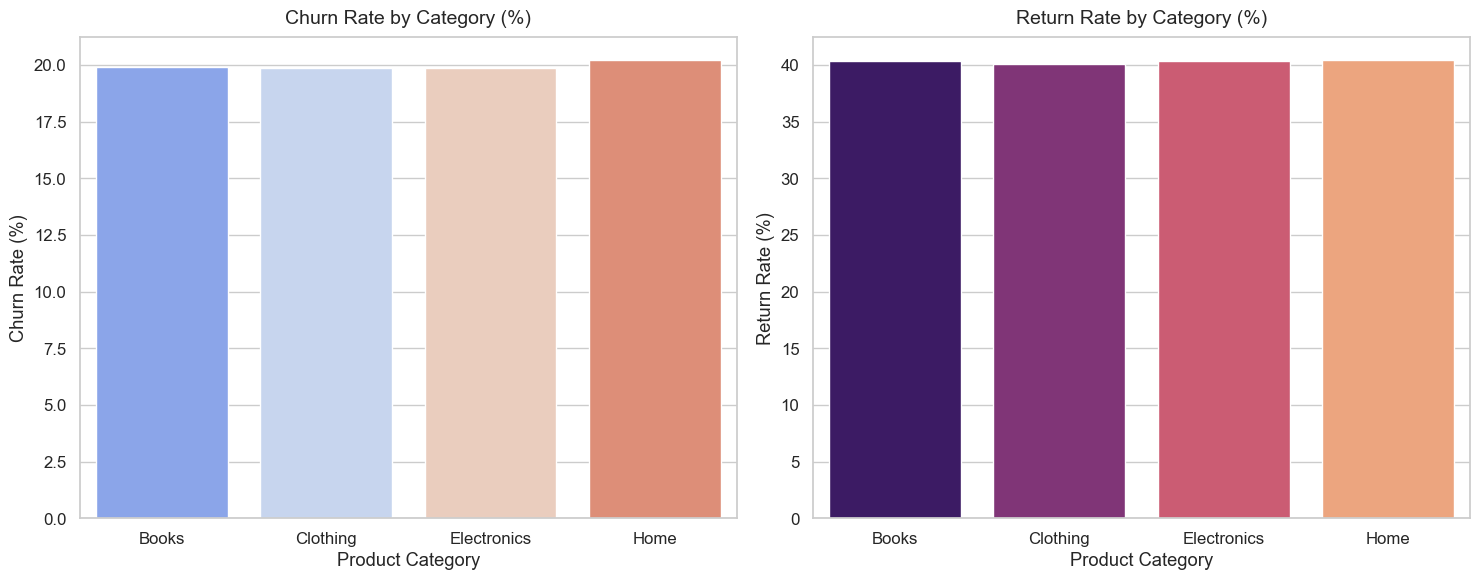

In [4]:
if 'df' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    churn_rate = df.groupby('Product Category')['Churn'].mean() * 100
    sns.barplot(x=churn_rate.index, y=churn_rate.values, hue=churn_rate.index, palette='coolwarm', ax=axes[0], legend=False)
    axes[0].set_title('Churn Rate by Category (%)', fontsize=14, pad=10)
    axes[0].set_ylabel('Churn Rate (%)')
    
    return_rate = df.groupby('Product Category')['Returns'].mean() * 100
    sns.barplot(x=return_rate.index, y=return_rate.values, hue=return_rate.index, palette='magma', ax=axes[1], legend=False)
    axes[1].set_title('Return Rate by Category (%)', fontsize=14, pad=10)
    axes[1].set_ylabel('Return Rate (%)')
    
    plt.tight_layout()
    plt.show()

**Insight:** Categories exhibiting the highest return rates might require quality inspections or better product descriptions on the website. High churn categories might need re-engagement campaigns.

---
## 4. Correlation Analysis
To round out the exploratory analysis, we examine the linear relationships between numeric variables (e.g., Age, Price, Quantity, Returns, Churn) via a correlation heatmap.

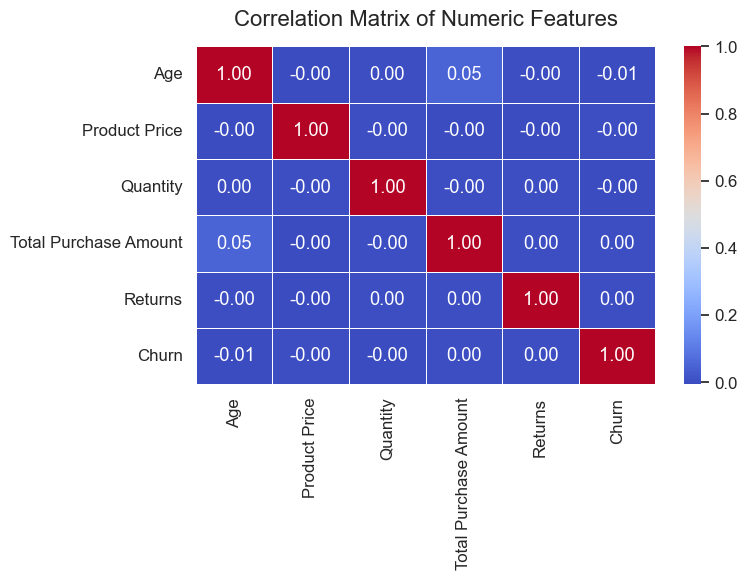

In [5]:
if 'df' in locals():
    plt.figure(figsize=(8, 6))
    numeric_cols = ['Age', 'Product Price', 'Quantity', 'Total Purchase Amount', 'Returns', 'Churn']
    corr_matrix = df[numeric_cols].corr()
    
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Correlation Matrix of Numeric Features', fontsize=16, pad=15)
    plt.tight_layout()
    plt.show()

**Insight:** The heatmap highlights any strong synergies (e.g., Price vs Total Purchase Amount) or potential red flags (e.g., correlation between Returns and Churn).

---
## Conclusion & Next Steps
- **Marketing:** Focus campaigns towards the peak demographic age groups. Tailor messaging corresponding to the most profitable categories.
- **Operations:** Investigate product quality for categories with elevated return rates.
- **Retention:** Proactively identify at-risk customers in high-churn categories by analyzing their return behavior.

_End of Exploratory Report_